<a href="https://colab.research.google.com/github/Anantmishra1907/Data-Science-/blob/main/Zomato_data_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importinmg python libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Creating The data Frame

In [ ]:
dataFrame = pd.read_csv("/content/Zomato_data.csv");
print(dataFrame.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


# Data Cleaning and preparation

In [ ]:
def handleRate(value):
  value = str(value).split('/')
  value = value[0];
  return value;
dataFrame['rate'] = dataFrame['rate'].apply(handleRate);
print(dataFrame.head())

                    name online_order book_table rate  votes  \
0                  Jalsa          Yes        Yes  4.1    775   
1         Spice Elephant          Yes         No  4.1    787   
2        San Churro Cafe          Yes         No  3.8    918   
3  Addhuri Udupi Bhojana           No         No  3.7     88   
4          Grand Village           No         No  3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


## Getting Summary of the data

In [ ]:
dataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


## Checking the missing value

In [ ]:
print(dataFrame.isnull().sum())



name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


In [ ]:
# Exploring the restaurent Types

Text(0, 0.5, 'Count')

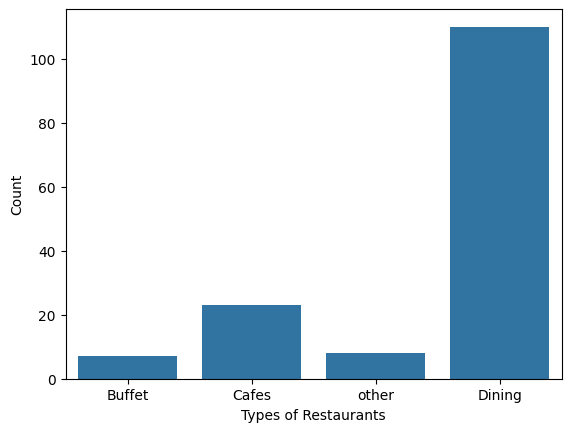

In [ ]:
sns.countplot(x = dataFrame['listed_in(type)'])
plt.xlabel("Types of Restaurants")
plt.ylabel("Count")

## votes by restaurant

Text(0, 0.5, 'Votes')

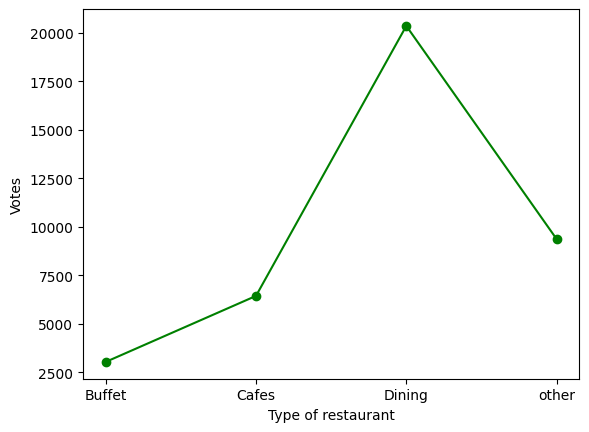

In [ ]:
grouped_data = dataFrame.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c='green', marker='o')
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')

## most Voted restaurant

In [ ]:
maxvoted = dataFrame['votes'].max()
print(dataFrame[dataFrame['votes'] == maxvoted])


                 name online_order book_table rate  votes  \
38  Empire Restaurant          Yes         No  4.4   4884   

    approx_cost(for two people) listed_in(type)  
38                          750           other  


## Online order Availability

<Axes: xlabel='online_order', ylabel='count'>

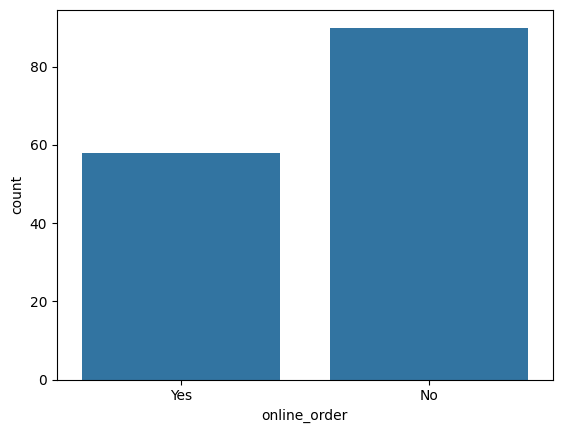

In [ ]:
sns.countplot(x = dataFrame['online_order'])

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

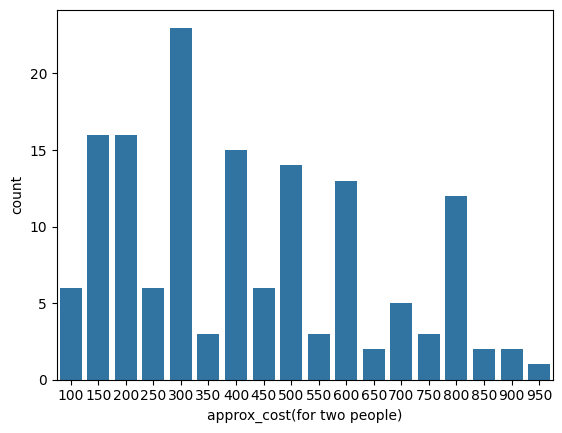

In [ ]:
couple_data=dataFrame['approx_cost(for two people)']
sns.countplot(x=couple_data)

# Rating comparison

<Axes: xlabel='online_order', ylabel='rate'>

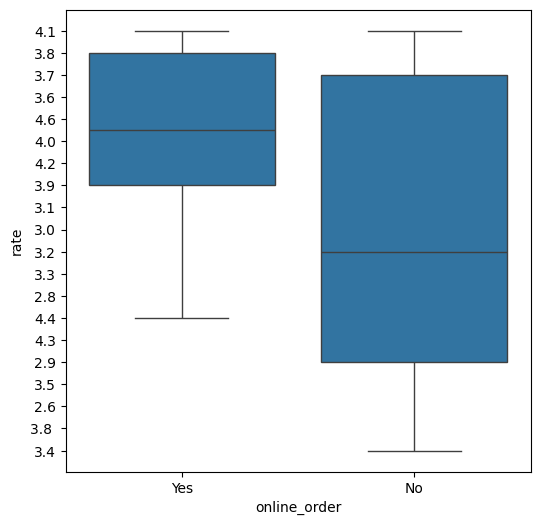

In [ ]:
plt.figure(figsize= (6 , 6))
sns.boxplot(x = 'online_order', y = 'rate' , data = dataFrame)